In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split
from io import StringIO

In [6]:
df = pd.read_csv("milknew.csv")
df_original = df.copy()
df.head(3)

,pH,Temprature,Taste,Odor,Fat,Turbidity,Colour,Grade
0,6.6,35,1,0,1,0,254,high
1,6.6,36,0,1,0,1,253,high
2,8.5,70,1,1,1,1,246,low


In [7]:
df.isnull().sum()

,0
pH,0
Temprature,0
Taste,0
Odor,0
Fat,0
Turbidity,0
Colour,0
Grade,0


In [8]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

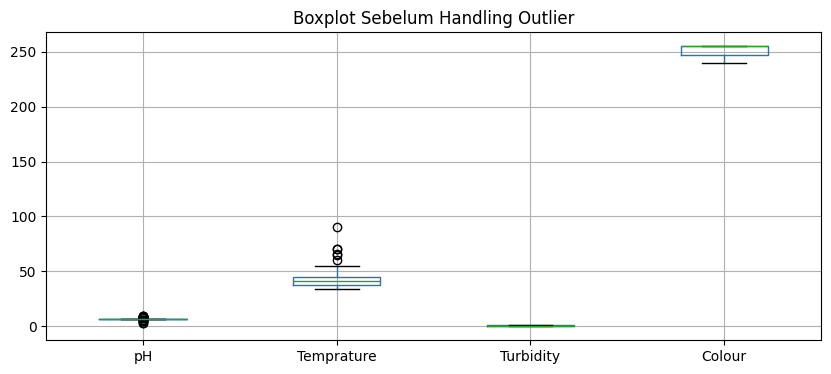

In [9]:
num_cols = ['pH', 'Temprature', 'Turbidity', 'Colour']
plt.figure(figsize=(10,4))
df[num_cols].boxplot()
plt.title("Boxplot Sebelum Handling Outlier")
plt.show()


In [10]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df = df[~((df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR)))]

In [11]:
scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])
df.head()

,pH,Temprature,Taste,Odor,Fat,Turbidity,Colour,Grade
0,0.50,0.047619,1,0,1,0.0,0.933333,high
1,0.50,0.095238,0,1,0,1.0,0.866667,high
4,0.50,0.142857,0,0,0,0.0,1.000000,medium
5,0.50,0.142857,1,1,1,1.0,1.000000,high
9,0.75,0.523810,1,1,0,0.0,0.466667,medium


In [12]:
scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])
df.head()

,pH,Temprature,Taste,Odor,Fat,Turbidity,Colour,Grade
0,0.50,0.047619,1,0,1,0.0,0.933333,high
1,0.50,0.095238,0,1,0,1.0,0.866667,high
4,0.50,0.142857,0,0,0,0.0,1.000000,medium
5,0.50,0.142857,1,1,1,1.0,1.000000,high
9,0.75,0.523810,1,1,0,0.0,0.466667,medium


In [13]:
encoder = OrdinalEncoder(categories=[['low', 'medium', 'high']])
df[['Grade']] = encoder.fit_transform(df[['Grade']])
df.head()

,pH,Temprature,Taste,Odor,Fat,Turbidity,Colour,Grade
0,0.50,0.047619,1,0,1,0.0,0.933333,2.0
1,0.50,0.095238,0,1,0,1.0,0.866667,2.0
4,0.50,0.142857,0,0,0,0.0,1.000000,1.0
5,0.50,0.142857,1,1,1,1.0,1.000000,2.0
9,0.75,0.523810,1,1,0,0.0,0.466667,1.0


In [14]:
df['Quality_Index'] = df['pH'] * df['Temprature']
df.head()

,pH,Temprature,Taste,Odor,Fat,Turbidity,Colour,Grade,Quality_Index
0,0.50,0.047619,1,0,1,0.0,0.933333,2.0,0.023810
1,0.50,0.095238,0,1,0,1.0,0.866667,2.0,0.047619
4,0.50,0.142857,0,0,0,0.0,1.000000,1.0,0.071429
5,0.50,0.142857,1,1,1,1.0,1.000000,2.0,0.071429
9,0.75,0.523810,1,1,0,0.0,0.466667,1.0,0.392857


In [15]:
X = df.drop(columns=['Grade'])
y = df['Grade']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((52, 8), (14, 8))

# POSTTEST 4

In [16]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

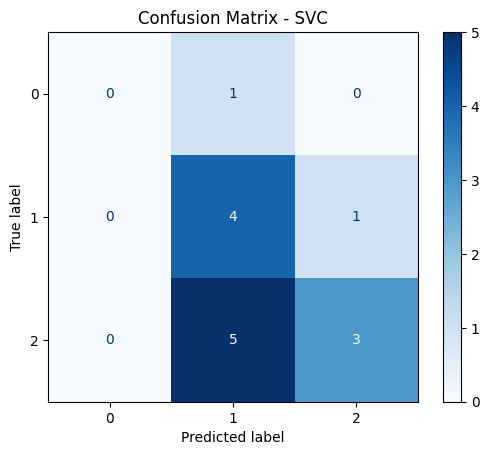

In [17]:
svc_model = SVC(kernel='rbf', random_state=42)
svc_model.fit(X_train, y_train)
y_pred = svc_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - SVC")
plt.show()

In [18]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         1
         1.0       0.40      0.80      0.53         5
         2.0       0.75      0.38      0.50         8

    accuracy                           0.50        14
   macro avg       0.38      0.39      0.34        14
weighted avg       0.57      0.50      0.48        14



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


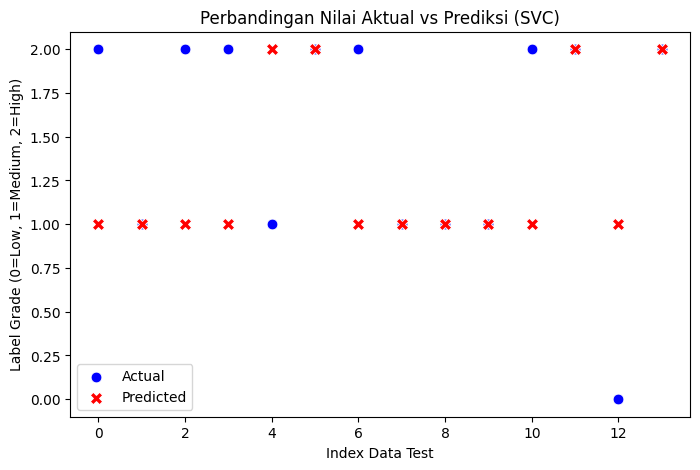

In [19]:

plt.figure(figsize=(8,5))
sns.scatterplot(x=range(len(y_test)), y=y_test, label='Actual', color='blue', s=60)
sns.scatterplot(x=range(len(y_pred)), y=y_pred, label='Predicted', color='red', marker='X', s=80)
plt.title("Perbandingan Nilai Aktual vs Prediksi (SVC)")
plt.xlabel("Index Data Test")
plt.ylabel("Label Grade (0=Low, 1=Medium, 2=High)")
plt.legend()
plt.show()

# Implementasi Model Klasifikasi
#Support Vector Classifier (SVC)
---
## 1️⃣ Algoritma yang Digunakan
Support Vector Machine (SVM) dengan `Support Vector Classifier (SVC)` digunakan untuk melakukan **klasifikasi label kategorikal (Grade)**.  
SVC bekerja dengan mencari **hyperplane terbaik** yang memisahkan tiap kelas (`low`, `medium`, `high`) pada ruang fitur secara maksimal.

Kernel yang digunakan adalah **RBF (Radial Basis Function)** karena cocok untuk data non-linear.

---

## 2️⃣ Proses Training dan Testing
- **Training set (80%)** digunakan untuk melatih model agar mengenali pola antar fitur.  
- **Testing set (20%)** digunakan untuk menguji performa model.

---

## 3️⃣ Evaluasi Model
### • Confusion Matrix
Menunjukkan jumlah prediksi benar dan salah untuk setiap kelas.
- Nilai diagonal menunjukkan prediksi yang **benar**.
- Nilai di luar diagonal menunjukkan prediksi **salah (misclassification)**.

### • Classification Report
Berisi metrik evaluasi berikut:
- **Precision:** Seberapa tepat model dalam memprediksi satu kelas.
- **Recall:** Seberapa banyak data benar yang berhasil diprediksi.
- **F1-score:** Kombinasi precision dan recall untuk melihat keseimbangan performa.
- **Accuracy:** Persentase keseluruhan prediksi benar.

---

## 4️⃣ Visualisasi Prediksi
Plot menampilkan:
- Titik **biru** = nilai aktual (label sebenarnya)
- Titik **merah X** = hasil prediksi model

Visualisasi ini membantu melihat apakah hasil prediksi mendekati nilai aktual.

---

## Kesimpulan
Model SVC digunakan karena:
- Label target bersifat **kategorikal (Grade)** → cocok untuk **klasifikasi**.
- Mampu menangani data non-linear dengan **kernel RBF**.
- Memberikan keseimbangan antara akurasi dan generalisasi.